In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

### PART 1

In [2]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#### Shapes of training and test

In [4]:
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape :", x_test.shape)
print("y_test shape :", y_test.shape)

x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape : (10000, 28, 28)
y_test shape : (10000,)


In [3]:
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

#### Displaying one image from each class

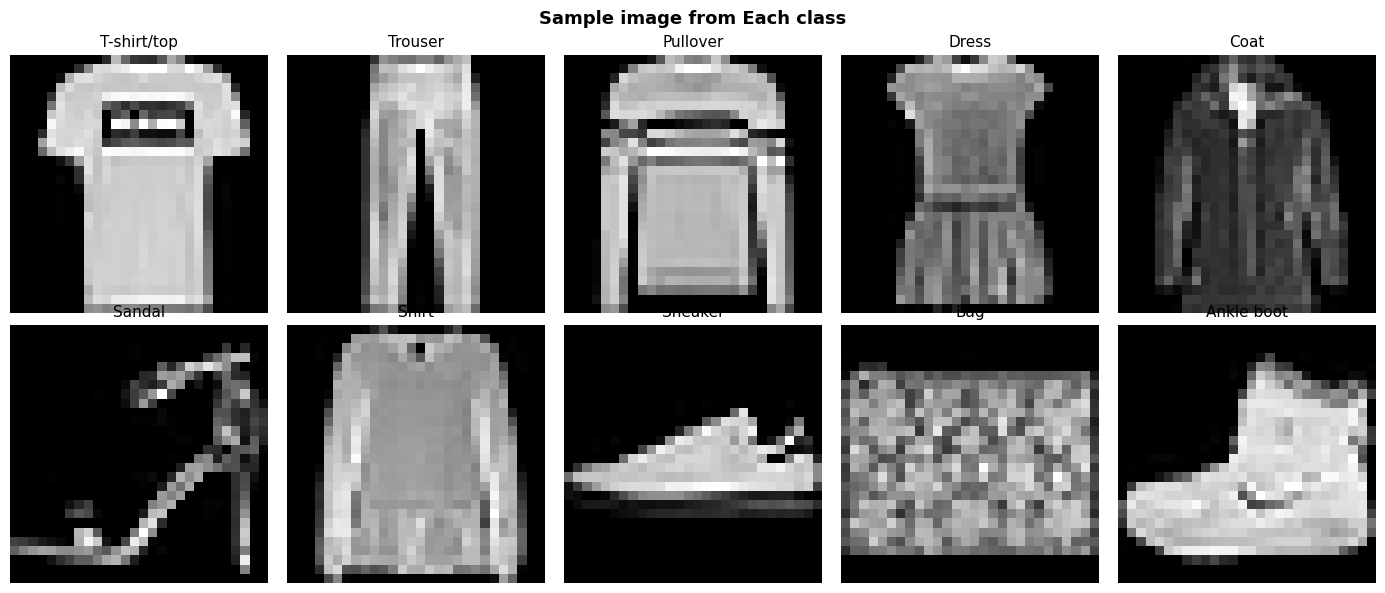

In [10]:
fig, axes = plt.subplots(2,5, figsize = (14,6))
axes = axes.flatten()
for class_idx in range(10):
  img_idx = np.where(y_train == class_idx)[0][0]
  axes[class_idx].imshow(x_train[img_idx], cmap = 'gray')
  axes[class_idx].set_title(class_names[class_idx], fontsize = 11)
  axes[class_idx].axis('off')
plt.suptitle("Sample image from Each class", fontsize = 13, fontweight = 'bold')
plt.tight_layout()
plt.show()

#### Normalizing pixel values

In [11]:
x_train = x_train / 255.0
x_test  = x_test  / 255.0

In [12]:
x_train.min()

np.float64(0.0)

In [13]:
x_train.max()

np.float64(1.0)

#### Reshaping for CNN Input

In [14]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test  = x_test.reshape(-1, 28, 28, 1)

In [16]:
x_train.shape

(60000, 28, 28, 1)

In [17]:
x_test.shape

(10000, 28, 28, 1)

Write UP:

Why is normalization required for image data?


Raw pixel values range from 0 to 255. Neural networks train using gradient based optimization. Large inputs cause large gradiets making the loss landscape steep and unstable training. Scaling these features in 0 and 1 ensures all input features are on same scale which speeds up convergence and prevents any single pixel from dominating the weight.

Why do CNNs require reshaped image inputs?

A CNNs convolutional layer performs 2D sliding window operations across spatial dimensions and independently across each channel. It expects a 4D tensor of shape (batch_size,height,width, and channel). Since the data only has three dimensions, it doesn;'t have channel dimension, reshaping it to 4 tells there is 1 grey scale channel, making it compatible with the convolutional layer.

### PART 2

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import time

In [19]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test, 10)

#### Designing and training

In [20]:
shallow_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')          # 10 classes
])
shallow_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 813,802 (3.10 MB)

 Trainable params: 813,802 (3.10 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
shallow_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
shallow_history = shallow_model.fit(
    x_train, y_train_cat,
    epochs=15,
    batch_size=64,
    validation_split=0.1,     # 10% of training data used for validation
    verbose=1
)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 121s 142ms/step - accuracy: 0.8431 - loss: 0.4466 - val_accuracy: 0.8878 - val_loss: 0.3109
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 143s 143ms/step - accuracy: 0.8952 - loss: 0.2917 - val_accuracy: 0.9042 - val_loss: 0.2590
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 140s 141ms/step - accuracy: 0.9117 - loss: 0.2385 - val_accuracy: 0.9130 - val_loss: 0.2351
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 141s 140ms/step - accuracy: 0.9246 - loss: 0.2036 - val_accuracy: 0.9180 - val_loss: 0.2277
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 117s 138ms/step - accuracy: 0.9354 - loss: 0.1763 - val_accuracy: 0.9218 - val_loss: 0.2166
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 119s 141ms/step - accuracy: 0.9440 - loss: 0.1538 - val_accuracy: 0.9190 - val_loss: 0.2286
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 145s 144ms/step - accuracy: 0.9496 - loss: 0.1341 - val_accuracy: 0.9263 - val_loss: 0.2287
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 149s 153ms/step - accuracy: 0.9561 -

#### Evaluating

In [23]:
shallow_test_loss, shallow_test_acc = shallow_model.evaluate(x_test, y_test_cat, verbose=0)

In [24]:
shallow_test_loss, shallow_test_acc

(0.34819942712783813, 0.9217000007629395)

#### Plotting

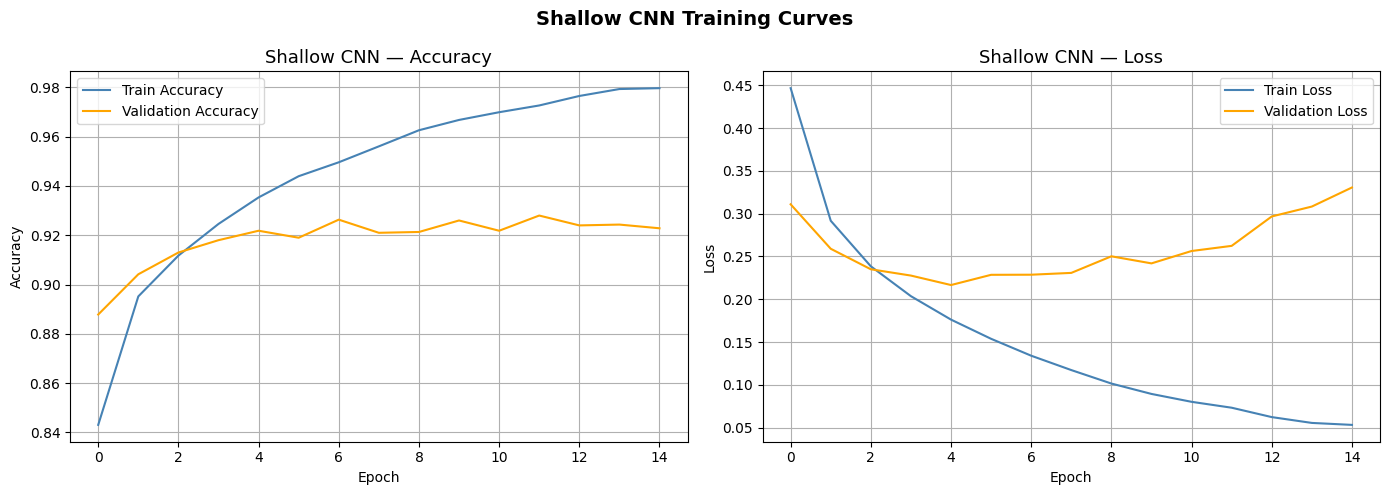

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(shallow_history.history['accuracy'],     label='Train Accuracy',      color='steelblue')
axes[0].plot(shallow_history.history['val_accuracy'], label='Validation Accuracy', color='orange')
axes[0].set_title('Shallow CNN — Accuracy', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(shallow_history.history['loss'],     label='Train Loss',      color='steelblue')
axes[1].plot(shallow_history.history['val_loss'], label='Validation Loss', color='orange')
axes[1].set_title('Shallow CNN — Loss', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Shallow CNN Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

WRITE UP:

What kind of patterns do you expect a shallow CNN to learn?

A shallow CNN with only 1-2 convolutional layers learns low level features like edges, corners, color gradients and simple textures. It doesn't have enough depth to combine these into higher level concepts such as deails of objects. The model will be able to distinguish broad categories but will struggle with similar classes like shirt vs tshirt.

Did the model show signs of underfitting or overfitting?

The model shows the signs of mild to moderate overfitting, since the training accuracy reached 97.9% while validation and test accuracy is around 92.2% which means it has some signs of overfitting.

### PART 3

#### Designing and training

In [30]:
deep_model = Sequential([
    # Block 1
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),

    # Block 2
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),

    # Block 3
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

deep_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 468,202 (1.79 MB)

 Trainable params: 468,202 (1.79 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
deep_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [34]:
start_time = time.time()

deep_history = deep_model.fit(
    x_train, y_train_cat,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

deep_train_time = time.time() - start_time

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 259s 304ms/step - accuracy: 0.7869 - loss: 0.5822 - val_accuracy: 0.8707 - val_loss: 0.3380
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 277s 321ms/step - accuracy: 0.8807 - loss: 0.3294 - val_accuracy: 0.9040 - val_loss: 0.2521
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 303s 299ms/step - accuracy: 0.9042 - loss: 0.2670 - val_accuracy: 0.9005 - val_loss: 0.2630
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 251s 298ms/step - accuracy: 0.9141 - loss: 0.2352 - val_accuracy: 0.9150 - val_loss: 0.2245
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 252s 298ms/step - accuracy: 0.9249 - loss: 0.2101 - val_accuracy: 0.9162 - val_loss: 0.2232
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 255s 302ms/step - accuracy: 0.9302 - loss: 0.1920 - val_accuracy: 0.9113 - val_loss: 0.2367
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 255s 302ms/step - accuracy: 0.9366 - loss: 0.1729 - val_accuracy: 0.9210 - val_loss: 0.2194
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 259s 298ms/step - accuracy: 0.9428 -

#### Evaluating on test set

In [35]:
deep_test_loss, deep_test_acc = deep_model.evaluate(x_test, y_test_cat, verbose=0)

In [36]:
deep_test_acc, deep_test_loss

(0.9230999946594238, 0.284284770488739)

In [56]:
deep_train_time/60

64.98282602628072

#### Plotting

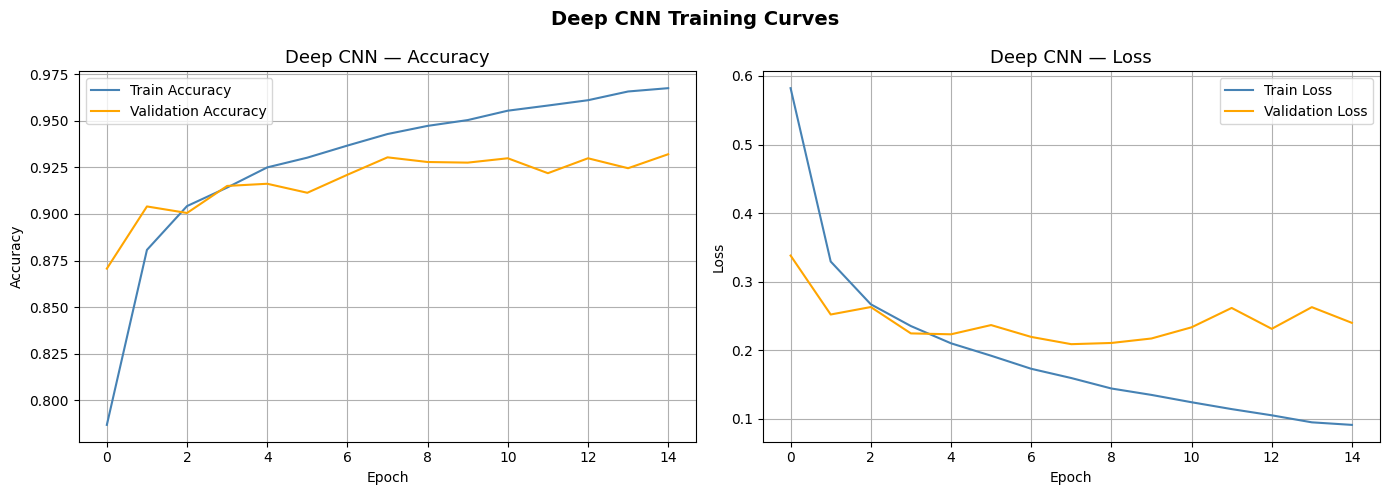

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(deep_history.history['accuracy'],     label='Train Accuracy',      color='steelblue')
axes[0].plot(deep_history.history['val_accuracy'], label='Validation Accuracy', color='orange')
axes[0].set_title('Deep CNN — Accuracy', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(deep_history.history['loss'],     label='Train Loss',      color='steelblue')
axes[1].plot(deep_history.history['val_loss'], label='Validation Loss', color='orange')
axes[1].set_title('Deep CNN — Loss', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Deep CNN Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Write UP:

What additional patterns or representations might a deep CNN learn?

The deep CNN starts with first block where it learns low level features like edges, corners, and textures.

Next block learns mild patterns like straps, collars soles handles.

And the final block assembles them into high level representations. This hierarchy allows deep CNN to distinguish visually similar classes that shallow CNN struggles.

Did the deeper model improve performance meaningfully?

The deeper model didn't improve test accuracy meaningfully, only a marginal gain of 0.14 % over the shallow CNN. However the validation loss has been reduced from 0.33 to 0.24, that means it makes better predictions. Also, the overfitting gap has been reduced from 5.7 % to 3.5 % that means its slightly better.

PART 4

#### COMPARISON TABLE

In [57]:
import pandas as pd
shallow_train_acc = shallow_history.history['accuracy'][-1]
shallow_val_acc   = shallow_history.history['val_accuracy'][-1]
deep_train_acc    = deep_history.history['accuracy'][-1]
deep_val_acc      = deep_history.history['val_accuracy'][-1]

shallow_conv_layers = 2
deep_conv_layers    = 5

shallow_params = shallow_model.count_params()
deep_params    = deep_model.count_params()

comparison_data = {
    'Metric': [
        'Number of Conv Layers',
        'Total Parameters',
        'Training Accuracy',
        'Validation Accuracy',
        'Test Accuracy',
        'Overfitting Observed?',
        'Training Time (seconds)'
    ],
    'Shallow CNN': [
        shallow_conv_layers,
        shallow_params,
        f"{shallow_train_acc*100:.2f}%",
        f"{shallow_val_acc*100:.2f}%",
        f"{shallow_test_acc*100:.2f}%",
        'Yes (gap 5.7%)',
        f"33 Mins"
    ],
    'Deep CNN': [
        deep_conv_layers,
        deep_params,
        f"{deep_train_acc*100:.2f}%",
        f"{deep_val_acc*100:.2f}%",
        f"{deep_test_acc*100:.2f}%",
        'Mild (gap 3.5%)',
        f"64.9 mins"
    ]
}

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))

                 Metric    Shallow CNN        Deep CNN
  Number of Conv Layers              2               5
       Total Parameters         813802          468202
      Training Accuracy         97.97%          96.74%
    Validation Accuracy         92.28%          93.20%
          Test Accuracy         92.17%          92.31%
  Overfitting Observed? Yes (gap 5.7%) Mild (gap 3.5%)
Training Time (seconds)        33 Mins       64.9 mins


In [41]:
### I forgot to add time.time() during shallow CNN, but the training time came up in google collab, it was approximately 33 mins and a few seconds.

#### Write up:
Which model performed better overall?

Both models performed comparably well. The deep CNN achieved a higher test accuracy compared to shallow, and had lower validation loss, making the deep CNN better calibrated overall.

#### Did the deep CNN justify its added complexity?

Not significantly. It has 5 conv layers and considerably more parameters than shallow CNN, yet test accuracy gain was only 0.14 %. So the added complexity didn't translate into a meaningful boost.

Which model generalized better?

Deep CNN generalized better since its train vs validation accuracy gap was 3.5% indicating less overfitting compared to shallow CNN

What tradeoff did you observe between simplicity and performance?

Shallow CNN was faster to train, and achieved nearly same accuracy as deep CNN. Deep CNN took long time to train but offered marginally better generalization. The trade off was the time. The Deep CNN took nearly double the time compared to shallow CNN.

### PART 5

In [42]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

#### Predictions on test set for both

In [43]:
shallow_pred_probs = shallow_model.predict(x_test)
shallow_pred       = np.argmax(shallow_pred_probs, axis=1)

deep_pred_probs    = deep_model.predict(x_test)
deep_pred          = np.argmax(deep_pred_probs, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step


In [44]:
y_true = y_test.flatten()

#### Correct and incorrect predictions

In [46]:
def show_predictions(y_true, y_pred, model_name, class_names, n=5):
    correct_idx   = np.where(y_true == y_pred)[0]
    incorrect_idx = np.where(y_true != y_pred)[0]

    fig, axes = plt.subplots(2, n, figsize=(15, 6))
    fig.suptitle(f'{model_name} — Correct (top) vs Incorrect (bottom)',
                 fontsize=13, fontweight='bold')

    # Top row: Correct predictions
    for i in range(n):
        idx = correct_idx[i]
        axes[0, i].imshow(x_test[idx].reshape(28, 28), cmap='gray')
        axes[0, i].set_title(f"Actual: {class_names[y_true[idx]]}\n"
                             f"Pred: {class_names[y_pred[idx]]}",
                             fontsize=8, color='green')
        axes[0, i].axis('off')

    # Bottom row: Incorrect predictions
    for i in range(n):
        idx = incorrect_idx[i]
        axes[1, i].imshow(x_test[idx].reshape(28, 28), cmap='gray')
        axes[1, i].set_title(f"Actual: {class_names[y_true[idx]]}\n"
                             f"Pred: {class_names[y_pred[idx]]}",
                             fontsize=8, color='red')
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

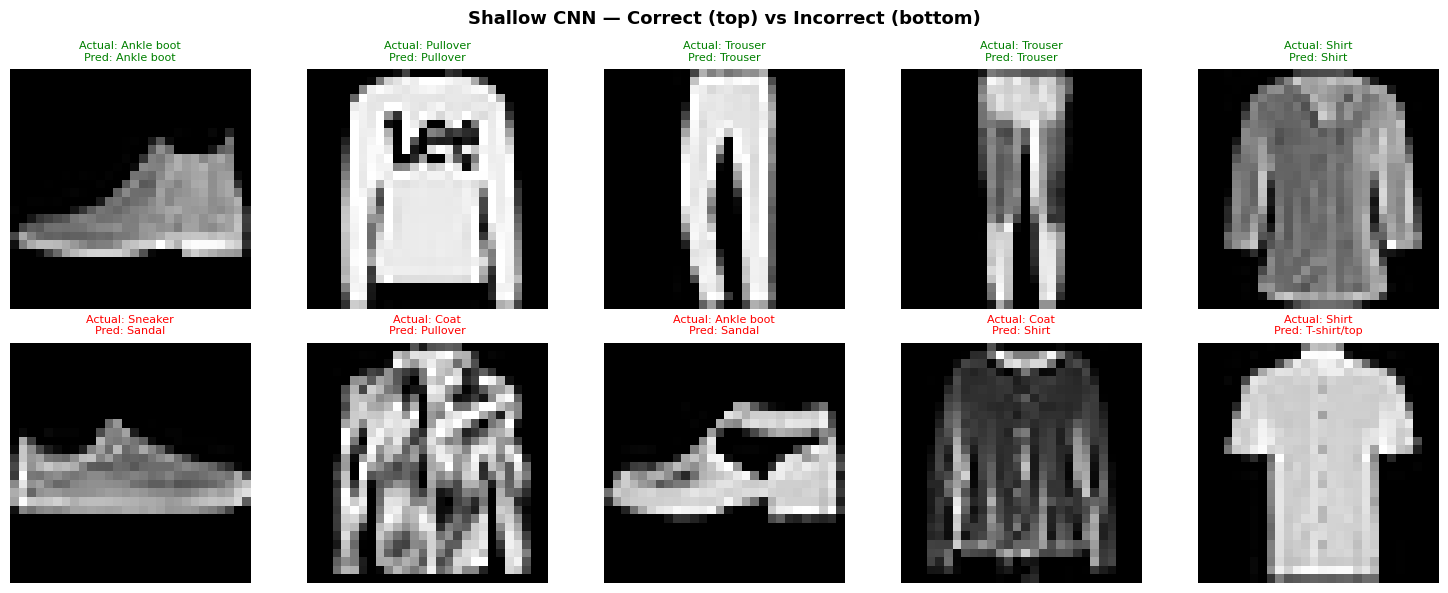

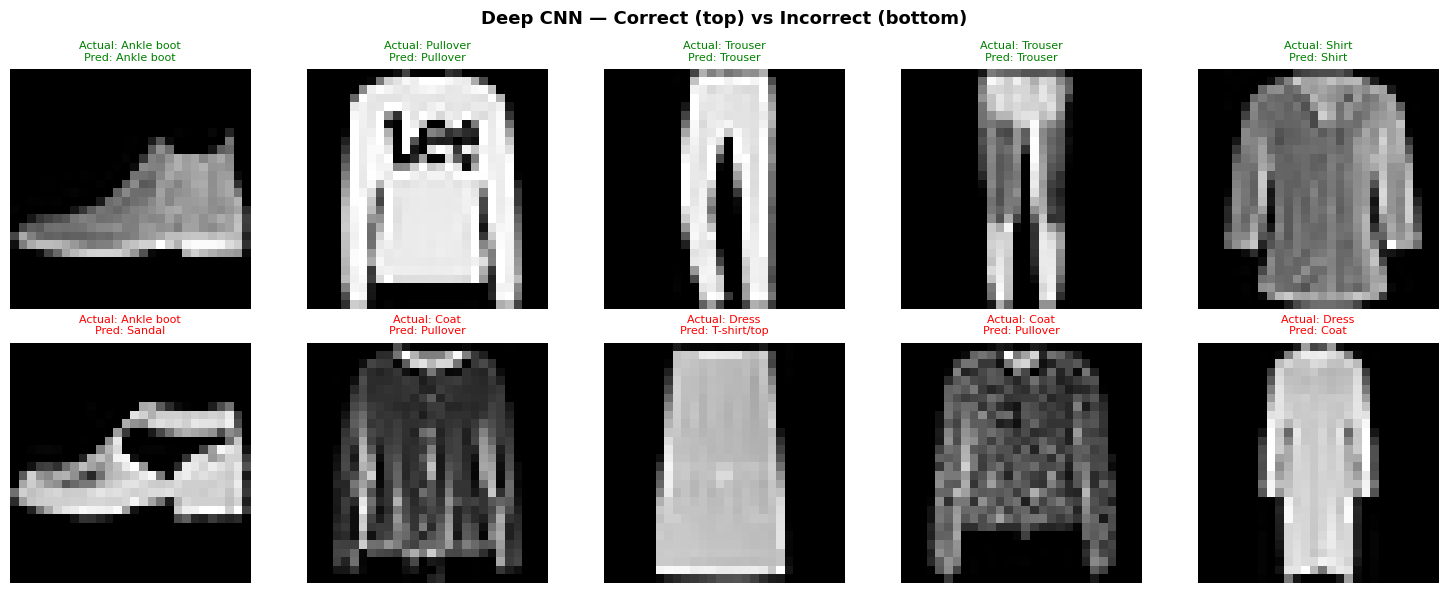

In [47]:
show_predictions(y_true, shallow_pred, 'Shallow CNN', class_names)
show_predictions(y_true, deep_pred,    'Deep CNN',    class_names)

#### Confusion matrix - SHallow CNN

In [48]:
cm_shallow = confusion_matrix(y_true, shallow_pred)

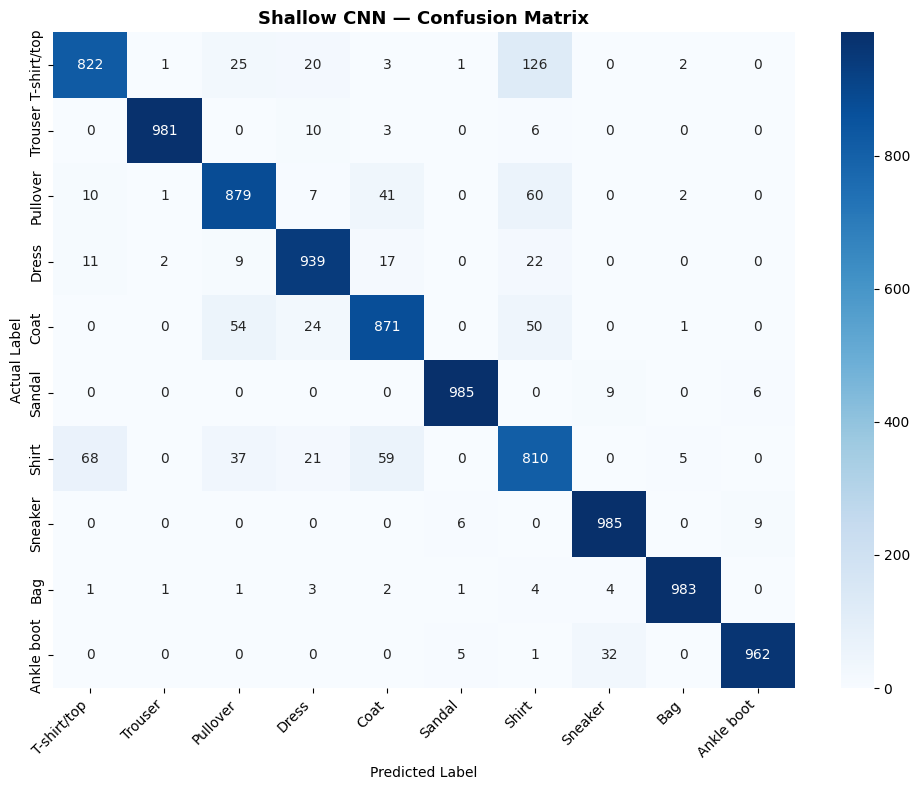

In [49]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm_shallow, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Shallow CNN — Confusion Matrix', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Confusion matrix - deep CNN

In [50]:
cm_deep = confusion_matrix(y_true, deep_pred)

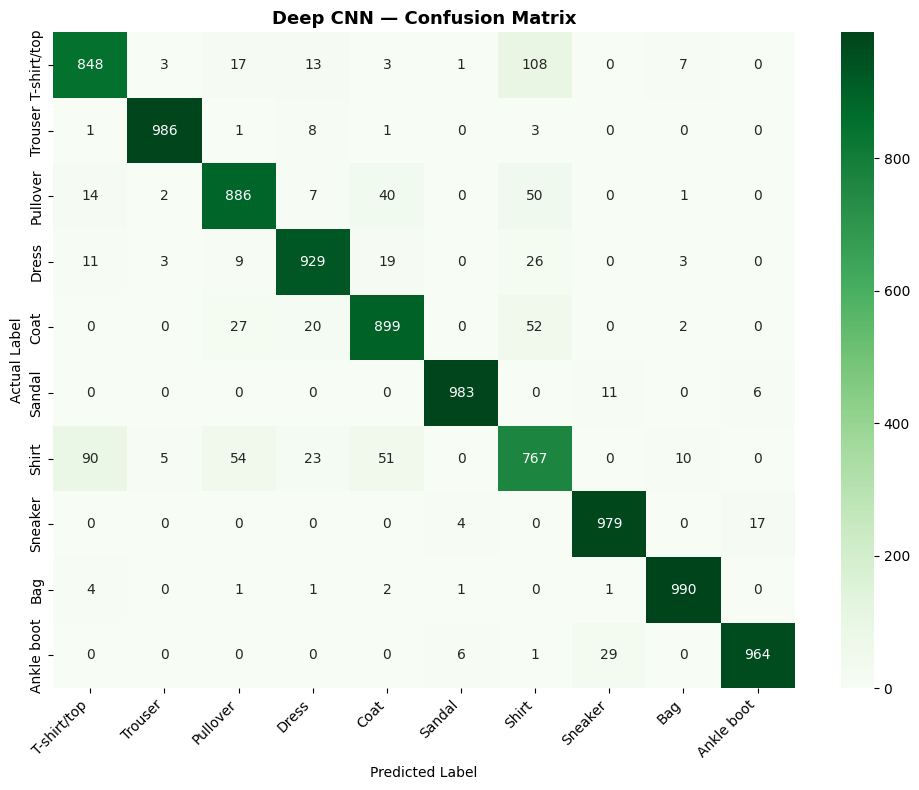

In [51]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm_deep, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Deep CNN — Confusion Matrix', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Write up
Which classes were easiest to classify?

Trouser, sneaker, bag, and sandle were easiest to classify as per the confusion matrix

Which classes were commonly confused?

Shirt was the most confused class. Tshirt was the confused with shirt. Also pullover was confused with coat.

Did the Deep CNN reduce the confusion?

The Deep CNN reduced confusion in some areas: Tshirt/top improved from 822 to 844 correct and bag improved from 983 to 990. However, shirt actually got worse, dropping from 810 to 767 correct. The confusion between pullover and coat remained nearly identical. So deep CNN didn't remove much confusion.

### PART 6

Which model would you recommend for Fashion-MNIST?

I would recommend shallow CNN. It achieved a test accuracy of 92.17 % (nearly identical to deep CNN)

Which model was more efficient?

The shallow CNN was more efficient. In nearly 33 mins, it gave better accuracy (only 0.14% lesser than deep CNN).

Which model was more accurate?

Deep CNN was marginally more accurate compared to shallow CNN. Also, deep CNN had lower validation loss and a smaller overfitting gap compared to Shallow CNN.

What did you learn from this study?

For me, this study revealed that more complexity doesn't always mean better performance. The deep CNN had 5 layers, more filters and took nearly twice compared to shallow, yet only 0.14 % increase in test accuracy. Model architecture should match dataset complexity.